In [148]:
#THIS FUNCTION IS FOR RUNNING WITH SLURM JOB ARRAY
#(SPLITS UP JOB_ARRAY BELOW INTO EVEN MORE TASKS)
def StartSlurmJobArray(num_jobs,num_slurm_jobs, ISRUN):
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=1
    if ISRUN==False:
        start_job=1;end_job=num_jobs+1
        return start_job,end_job
    total_elements=num_jobs #total num of variables

    job_range = total_elements // num_slurm_jobs  # Base size for each chunk
    remaining = total_elements % num_slurm_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_slurm_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_slurm_jobs - 1: 
            end_job = total_elements 
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_slurm_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()

    # if sbatch==True:
        
    start_job, end_job = get_job_range(job_id, num_slurm_jobs)
    index_adjust=start_job
    # print(f'start_job = {start_job}, end_job = {end_job}')
    if start_job==0: start_job=1
    return start_job,end_job

# job_id=1
# [start_slurm_job,end_slurm_job,slurm_index_adjust]=StartSlurmJobArray(num_jobs,num_slurm_jobs,ISRUN)
# parcel=parcel1.isel(xh=slice(start_job,end_job))

In [149]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel1=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [150]:
times=data1['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
kms=np.argmax(data1['xh'].values-data1['xh'][0].values >= 1)

In [151]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [152]:
########################
#READING BACK IN
def LoadFinalData(in_file):
    dict = {}
    with h5py.File(in_file, 'r') as f:
        for key in f.keys():
            dict[key] = f[key][:]
    return dict

def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
in_file=dir2+f"parcel_tracking_SUBSET_{res}_{t_res}_{Np_str}"
final_dict=LoadFinalData(in_file)


#DYNAMICALLY CREATING VARIABLES
for key, value in final_dict.items():
    globals()[key] = value

# #DYNAMICALLY PRINTING VARIABLE SIZES
# for key in final_dict:
#     print(f"{key} has {final_dict[key].shape[0]} parcels")

# PRINTING VARIABLE SIZES (ONE BY ONE)
print(f'ALL: {len(CL_ALL_out_arr)} CL parcels and {len(nonCL_ALL_out_arr)} nonCL parcels')
print(f'SHALLOW: {len(CL_SHALLOW_out_arr)} CL parcels and {len(nonCL_SHALLOW_out_arr)} nonCL parcels')
print(f'DEEP: {len(CL_DEEP_out_arr)} CL parcels and {len(nonCL_DEEP_out_arr)} nonCL parcels')
print('\n')
print(f'ALL: {len(SBZ_ALL_out_arr)} SBZ parcels and {len(nonSBZ_ALL_out_arr)} nonSBZ parcels')
print(f'SHALLOW: {len(SBZ_SHALLOW_out_arr)} SBZ parcels and {len(nonSBZ_SHALLOW_out_arr)} nonSBZ parcels')
print(f'DEEP: {len(SBZ_DEEP_out_arr)} SBZ parcels and {len(nonSBZ_DEEP_out_arr)} nonSBZ parcels')
print('\n')
print(f'ALL: {len(ColdPool_ALL_out_arr)} ColdPool parcels')
print(f'SHALLOW: {len(ColdPool_SHALLOW_out_arr)} ColdPool parcels')
print(f'DEEP: {len(ColdPool_DEEP_out_arr)} ColdPool parcels')


def apply_job_array_filter(start_job, end_job):
    # print("APPLYING JOB ARRAY")

    def job_filter(arr):
        return arr[(arr[:, 0] >= start_job) & (arr[:, 0] < end_job)]

    target_names = [
        'CL_ALL_out_arr', 'nonCL_ALL_out_arr',
        'CL_SHALLOW_out_arr', 'nonCL_SHALLOW_out_arr',
        'CL_DEEP_out_arr', 'nonCL_DEEP_out_arr',
        'SBZ_ALL_out_arr', 'nonSBZ_ALL_out_arr',
        'SBZ_SHALLOW_out_arr', 'nonSBZ_SHALLOW_out_arr',
        'SBZ_DEEP_out_arr', 'nonSBZ_DEEP_out_arr',
        'ColdPool_ALL_out_arr', 'ColdPool_SHALLOW_out_arr', 'ColdPool_DEEP_out_arr'
    ]

    for name in target_names:
        globals()[name+'_2'] = job_filter(globals()[name])

Minimum Cloudbase is: 1.2463867664337158

ALL: 14630 CL parcels and 10991 nonCL parcels
SHALLOW: 10059 CL parcels and 8367 nonCL parcels
DEEP: 1489 CL parcels and 1112 nonCL parcels


ALL: 815 SBZ parcels and 13815 nonSBZ parcels
SHALLOW: 424 SBZ parcels and 9635 nonSBZ parcels
DEEP: 187 SBZ parcels and 1302 nonSBZ parcels


ALL: 13815 ColdPool parcels
SHALLOW: 9635 ColdPool parcels
DEEP: 1302 ColdPool parcels


In [153]:
################################
#JOB ARRAY SETUP
################################
#*#*
# how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100
num_jobs=60 #1M parcels
# num_jobs=200 #50M parcels
##############################

In [154]:
##############################################
#DATA LOADING FUNCTIONS

In [155]:
#JOB ARRAY SETUP
def StartJobArray(job_id,num_jobs):
    total_elements=len(parcel1['xh']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements #- 1
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()

    # if sbatch==True:
    #     job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    #     if job_id==0: job_id=1
        
    start_job, end_job = get_job_range(job_id, num_jobs)
    index_adjust=start_job
    # print(f'start_job = {start_job}, end_job = {end_job}')
    return start_job,end_job,index_adjust

# job_id=1
# [start_job,end_job,index_adjust]=StartJobArray(job_id,num_jobs)
# parcel=parcel1.isel(xh=slice(start_job,end_job))

In [156]:
# Reading Back Data Later
##############
def make_data_dict(in_file,var_names,read_type,start_job,end_job):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
           data_dict = {var_name: f[var_name][:,start_job:end_job] for var_name in var_names}
            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        data_dict = {k: in_data[k][:,start_job:end_job].compute().data for k in var_names}
    return data_dict

# read_type='xarray'
read_type='h5py'

In [157]:
def MakeDataDictionary(**vars):
    return vars
    
def GetData(start_job,end_job):
    dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
    in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
    
    var_names = ['W']
    data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
    [W] = (data_dict[k] for k in var_names)
    
    # #Making Time Matrix
    # rows, cols = A.shape[0], A.shape[1]
    # T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)
    
    dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
    in_file=dir2+f'VARS_binary_array_{res}_{t_res}_{Np_str}.h5'
    
    var_names = ['QV','TH']
    data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
    QV, TH = [data_dict[k] for k in var_names]

    VARs=MakeDataDictionary(W=W, TH=TH, QV=QV)
    return VARs
# VARs=GetData(start_job,end_job)

In [158]:
def GetSpatialData(start_job,end_job):
    dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
    in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
    
    var_names = ['A_g','A_c', 'Z','Y','X','z']
    data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
    A_g,A_c, Z,Y,X,parcel_z = (data_dict[k] for k in var_names)
    
    # #Making Time Matrix
    # rows, cols = A.shape[0], A.shape[1]
    # T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)
    
    return A_g,A_c, Z,Y,X,parcel_z
# [A_g,A_C, Z,Y,X,parcel_z] = GetSpatialData(start_job,end_job) 

In [159]:
##########################
#SETUP SECTION

In [160]:
zfs=data1['zf'].data*1000
times=(data1['time'].data / 1e9).astype(int)
Nt=len(data1['time'])

In [161]:
##########################
#BUILDING HISTOGRAM FUNCTIONS

In [162]:
# def SetupHistSampling(histz_vals, histt_vals):
#     # Process z levels
#     histz_str = np.array([str(z) for z in histz_vals])
#     histz = np.clip(np.searchsorted(zfs, histz_vals) - 1, 0, None)

#     # Process t levels
#     histt_str = np.array([str(t) for t in histt_vals])
#     histt_idx = np.clip(np.searchsorted(times, histt_vals, side='right') - 1, 0, None)
#     histt = [np.arange(0, ind + 1) for ind in histt_idx]

#     return histz, histt, histt_str, histz_str

#TESTING
def get_intervals_from_edges(histt_vals):
    extended = [0] + list(histt_vals)  # Add 0 as the starting point
    return [(extended[i], extended[i + 1]) for i in range(len(extended) - 1)]
def SetupHistSampling(histz_vals, histt_vals): #UP_TO
    # Process z levels
    histz_str = np.array([str(z) for z in histz_vals])
    histz = np.clip(np.searchsorted(zfs, histz_vals) - 1, 0, None)

    # Process t levels
    histt_str = np.array([str(t) for t in histt_vals])
    histt_idx = np.clip(np.searchsorted(times, histt_vals, side='right') - 1, 0, None)
    histt = [ind for ind in histt_idx]
    intervals=[(int(val)) for val in histt_vals] #only needed for plotting

    
    # if UP_TO==True:
    #     histt_idx = np.clip(np.searchsorted(times, histt_vals, side='right') - 1, 0, None)
    #     histt = [np.arange(0, ind + 1) for ind in histt_idx]
    #     intervals=[(0,int(val)) for val in histt_vals] #only needed for plotting
    # elif UP_TO==False:
    #     intervals = get_intervals_from_edges(histt_vals)
    #     histt_idx = np.clip(np.searchsorted(times, intervals, side='right') - 1, 0, None) #*#*#
    #     histt = [np.arange(start, end + 1) for start, end in histt_idx]
    # print(histt)
    return histz, histt, histt_str, histz_str, intervals

In [163]:
#INITIALIZE ALL HISTOGRAMS IN A DICTIONARY
def MakeDictionary(histz_str,histt_str,hist_size):
    
    # Create a 2D zero-initialized array (this is your histogram storage array)
    zero_histogram = np.zeros(hist_size,dtype=int)
    
    # Initialize a dictionary to store the histograms
    Histograms = {}
    #store each histogram in a dictionary
    for z in histz_str:
        for t in histt_str:        
            Histograms[f"{z}_{t}"] = np.copy(zero_histogram)
    
    return Histograms
# [bin_left1,bin_right1,num_bins1]=GetBinSettings(VAR1_name)
# [bin_left2,bin_right2,num_bins2]=GetBinSettings(VAR2_name)
# hist_size = (num_bins1,num_bins2)  

In [164]:
# #TESTING #*#*
# arr=VAR1_list.copy()
# overall_min = np.min(np.concatenate(arr))
# overall_max = np.max(np.concatenate(arr))
# print("Min:", overall_min*1000)
# print("Max:", overall_max*1000)

# arr=VAR2_list.copy()
# overall_min = np.min(np.concatenate(arr))
# overall_max = np.max(np.concatenate(arr))
# print("Min:", overall_min)
# print("Max:", overall_max)

# # ==>
# #QV
# #Min: 10.992669500410557
# #Max: 17.3798818141222
# #TH
# #Min: 301.20013
# #Max: 310.33856
# #W
# # Min: -5.313181
# # Max: 6.396657

In [165]:
#HISTOGRAM SETTINGS
def GetBinSettings(var_name):    
    nbin1=50;nbin2=50
    
    # pre_calculated=False
    pre_calculated=True
    if pre_calculated==False:
        bin_settings = {
            'qv':       (QV.min(), QV.max(), nbin1),
            'th':       (TH.min(), TH.max(), nbin2),
            'w':        (W.min(), W.max(), nbin1),
            
        }
    elif pre_calculated==True:
        bin_settings = {
            'qv': (11/1000, 18/1000, nbin2),
            'th': (302, 311, nbin2),
            'w': (-3, 7, nbin1),
        }
    # Select bin range based on var_name
    if var_name is not None and var_name in bin_settings:
        bin_left, bin_right, num_bins = bin_settings[var_name]
    else:
        # fallback default
        bin_left, bin_right, num_bins = -50, 50, 1000
    return bin_left,bin_right,num_bins

In [166]:
# def MakeHistogram(VAR1s,VAR2s,bin_left,bin_right,num_bins): #TEST VERSION
#     Output=np.ones((5000,5000),dtype=int)
#     return Output

def MakeHistogram(VAR1s,VAR2s,
                  bin_left1,bin_right1,num_bins1,
                  bin_left2,bin_right2,num_bins2): #*#*
    ###given two flattened arrays, will bin each value into 2D Histograms

    # Output =np.zeros((num_bins2, num_bins1)) 
    # bin_list1=np.linspace(bin_left1,bin_right1,num_bins1)
    # bin_list2=np.linspace(bin_left2,bin_right2,num_bins2)
    
    # Define bin edges
    bins_list1 = np.linspace(bin_left1, bin_right1, num_bins1 + 1)
    bins_list2 = np.linspace(bin_left2, bin_right2, num_bins2 + 1)

    # Compute 2D histogram
    Output, xedges, yedges = np.histogram2d(VAR2s, VAR1s, bins=[bins_list2, bins_list1])
    return Output.astype(int)

In [167]:
##########################
#BUILDING ALGORITHM FUNCTIONS

In [168]:
class BreakException(Exception):
    pass
def _BREAK_(var=None):
    print(var)
    raise BreakException 

#GET LAGRANGIAN SPATIAL ARRAYS
def GetSpace(t, p):#, X, Y, Z):
    z = Z[t, p]; zs = Z[t] 
    y = Y[t, p]; ys = Y[t]
    x = X[t, p]; xs = X[t]
    return z,y,x,zs,ys,xs

def SpaceConditional(z,y,x,D,zs,ys,xs):
    cond1 = D==1; cond2 = zs==z; 
    cond3 = ys==y; cond4 = xs==x
    #where the entrained parcels are in same grid box
    where=cond1&cond2&cond3&cond4 
    # print(np.where(cond1),np.where(cond2),np.where(cond3),np.where(cond4))
    # print(np.where(cond1&cond2&cond3))
    return where

#####
def Meshgrid_Advanced(ts, ps):
    t_grid, p_grid = np.meshgrid(ts, ps)
    return t_grid.flatten(), p_grid.flatten()

def SubsetZ(histz,t_lst,p_lst):
    Zs=Z[t_lst,p_lst]
    where_z = np.where(np.isin(Zs,histz))[0]
    t_lst=t_lst[where_z];p_lst=p_lst[where_z]
    return t_lst,p_lst,Zs

In [169]:
#FIND ENTRAINMENT PARCELS
def GetEntrainmentHistory(A,VAR1,VAR2,Dictionary,t,p):
    global VAR1_list,VAR2_list #TESTING #*#*
    if t<=np.max(histt):
        return Dictionary

    #marking entrained parcels
    D=A[t] - A[t-1]
    D=np.where(D>0,True,False)
    # _BREAK_(D)

    #getting some spatial variables
    [z,y,x,zs,ys,xs] = GetSpace(t,p)
    # _BREAK_((z,y,x,zs,ys,xs))
    if z not in histz:
        return Dictionary
    z_string=histz_str[histz == z][0]
    
    #locating entrained parcels 
    where = SpaceConditional(z,y,x,D,zs,ys,xs)
    # _BREAK_(np.where(where==True))
    ps=np.where(where)
    if ps[0].size==0:
        return Dictionary
    # else: #TESTING #*#*
    #     print(f'found particles at p={p}')
    #     # _BREAK_(ps)

    #get trackback trajectories
    for (ts,t_string) in zip(histt,histt_str):
        #meshgrid calculations 
        minus_ts=(t - ts)#[(t - ts) < Nt]
        # _BREAK_((minus_ts,ps))
        [t_flat,p_flat] = Meshgrid_Advanced(minus_ts, ps)
        
        # _BREAK_(t_flat)

        #get variable data along trajectory
        VAR1s = VAR1[t_flat,p_flat]
        VAR2s = VAR2[t_flat,p_flat]

        VAR1_list.append(VAR1s);VAR2_list.append(VAR2s)#TESTING #*#*

        #ADD HISTOGRAM TO A DICTIONARY
        Histogram = MakeHistogram(VAR1s,VAR2s,
                  bin_left1,bin_right1,num_bins1,
                  bin_left2,bin_right2,num_bins2)
        # _BREAK_(np.where(Histogram!=0))
        Dictionary[f'{z_string}_{t_string}'] += Histogram

    #return the updated dictionary
    return Dictionary
        

In [170]:
##########################
#LOADING DATA

In [171]:
##########################
#USER SET PARAMETERS

In [175]:
#ENTRAINMENT TYPE SET
type='general'
# type='cloudy

#VARIABLE SETUP
VAR1_name='qv'; 
VAR2_name='th';
# VAR2_name='w';

out_arr_name="CL_ALL_out_arr"

#HISTOGRAM SETUP PARAMETERS
histz_vals=[200,500,1000] #unit: meters
histt_vals=[0,300,600,900,1200] #unit:seconds

In [176]:
##########################
#SETTING UP SOME THINGS

In [177]:
def SetupData1(out_arr_name, A_c, A_g, type):
    #DATA SETUP
    ARR=globals()[out_arr_name][:,0:3].copy()
    A = A_c.copy() if type == 'cloudy' else A_g.copy()
    return ARR,A
# out_arr_name="CL_ALL_out_arr"
# [ARR, A] = SetupData1(out_arr_name, A_c, A_g, type)

def SetupData2(ARR):
    tp_coords=np.vstack([np.column_stack((np.repeat(p, t2 - t1 + 1), np.arange(t1, t2 + 1))) for p, t1, t2 in ARR])
    t_lst = tp_coords[:,1]; p_lst=tp_coords[:,0]
    VAR1_list=[];VAR2_list=[]
    return tp_coords, t_lst, p_lst, VAR1_list, VAR2_list
# tp_coords, t_lst, p_lst, VAR1_list, VAR2_list = SetupData2(ARR)

In [178]:
def SetupHistograms(VAR1_name, VAR2_name, histz_vals, histt_vals, t_lst, p_lst):
    #SET HISTOGRAMS HERE
    [bin_left1,bin_right1,num_bins1]=GetBinSettings(VAR1_name)
    [bin_left2,bin_right2,num_bins2]=GetBinSettings(VAR2_name)
    hist_size = (num_bins2,num_bins1)  
    
    #HISTOGRAM INFO
    [histz, histt, histt_str, histz_str, intervals] = SetupHistSampling(histz_vals, histt_vals) 
    [t_lst,p_lst,Zs]=SubsetZ(histz,t_lst,p_lst)#SUBSETTING DATA FOR Zs in histz (FOR FASTER SPEED)
    # print(histz,histt)
    
    #INITIALIZE HISTOGRAMS
    Dictionary = MakeDictionary(histz_str,histt_str,hist_size)

    return bin_left1, bin_right1, num_bins1, bin_left2, bin_right2, num_bins2, \
           hist_size, histz, histt, histt_str, histz_str, intervals, t_lst, p_lst, Zs, Dictionary
# bin_left1, bin_right1, num_bins1, \
# bin_left2, bin_right2, num_bins2, \
# hist_size, histz, histt, histt_str, histz_str, \
# intervals, t_lst, p_lst, Zs, Dictionary = SetupHistograms(
#     VAR1_name, VAR2_name, histz_vals, histt_vals, t_lst, p_lst
# )

In [179]:
def SaveProfile(Dictionary,VAR1_name,VAR2_name,job_id):
    ################
    #SAVING
    import pickle
    dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
    out_file=dir2+f"Entrainment_Trackback_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}"
    out_file+=f"_{job_id}.h5"
    with open(out_file, "wb") as f:
        pickle.dump(Dictionary, f)

In [180]:
# #TESTING THE ALGORITHM IS WORKING CORRECTLY 
# #ALSO TURN ON OLD MakeHistogram FUNCTION
# values, counts = np.unique(Zs[np.isin(Zs,histz)], return_counts=True)
# print(values)
# print(counts)

In [181]:
##########################
#RUNNING

In [182]:
def RunHistogram(A, VAR1, VAR2, Dictionary, t_lst, p_lst, VAR1_name, VAR2_name, job_id):
    for count, (t, p) in enumerate(zip(t_lst, p_lst)):
        if count % 500 == 0:
            print(f"{count}/{len(p_lst)}")
        Dictionary = GetEntrainmentHistory(A, VAR1, VAR2, Dictionary, t, p)
    SaveProfile(Dictionary, VAR1_name, VAR2_name, job_id)

    # #TESTING
    # for key in Dictionary:
    #     print(np.where(Dictionary[key]!=0))

In [183]:
num_slurm_jobs=30 #**#*
[start_slurm_job,end_slurm_job]=StartSlurmJobArray(num_jobs=num_jobs,num_slurm_jobs=num_slurm_jobs,ISRUN=False) #if ISRUN is False, then will not run using slurm_job_array

print(f"Running on Slurm_Jobs for Slurm_Job_Ids: {(start_slurm_job,end_slurm_job)}")

job_id_list=np.arange(start_slurm_job,end_slurm_job)
for job_id in job_id_list:
    if job_id % 1 == 0: print(f'current job_id = {job_id}')

    [start_job,end_job,index_adjust]=StartJobArray(job_id,num_jobs)

    #SLICING DATA
    parcel=parcel1.isel(xh=slice(start_job,end_job))
    apply_job_array_filter(start_job, end_job)

    #GETTING DATA AND PUTTING IN A DICTIONARY
    [A_g,A_c, Z,Y,X,parcel_z] = GetSpatialData(start_job,end_job) 
    VARs=GetData(start_job,end_job)
    VAR1=VARs[VAR1_name.upper()]; VAR2=VARs[VAR2_name.upper()]

    #HISTOGRAM SETTINGS
    [ARR, A] = SetupData1(out_arr_name+"_2", A_c, A_g, type)
    
    if len(ARR)==0: 
        Dictionary=MakeDictionary(histz_str,histt_str,hist_size)
        SaveProfile(Dictionary, VAR1_name, VAR2_name, job_id)
        continue
    ARR[:,0]-=index_adjust #ADJUSTING FOR JOB_ARRAY
    [tp_coords, t_lst, p_lst, VAR1_list, VAR2_list] = SetupData2(ARR)
    
    bin_left1, bin_right1, num_bins1, \
    bin_left2, bin_right2, num_bins2, \
    hist_size, histz, histt, histt_str, histz_str, \
    intervals, t_lst, p_lst, Zs, Dictionary = SetupHistograms(
        VAR1_name, VAR2_name, histz_vals, histt_vals, t_lst, p_lst
    )

    #RUNNING
    RunHistogram(A, VAR1, VAR2, Dictionary, t_lst, p_lst, VAR1_name, VAR2_name, job_id)

Running on Slurm_Jobs for Slurm_Job_Ids: (1, 60)
current job_id = 1
0/352
current job_id = 2
0/390
current job_id = 3
0/355
current job_id = 4
0/386
current job_id = 5
0/348
current job_id = 6
0/400
current job_id = 7
0/391
current job_id = 8
0/358
current job_id = 9
0/376
current job_id = 10
0/332
current job_id = 11
0/377
current job_id = 12
0/370
current job_id = 13
0/410
current job_id = 14
0/363
current job_id = 15
0/397
current job_id = 16
0/382
current job_id = 17
0/304
current job_id = 18
0/379
current job_id = 19
0/429
current job_id = 20
0/388
current job_id = 21
0/399
current job_id = 22
0/369
current job_id = 23
0/348
current job_id = 24
0/331
current job_id = 25
0/414
current job_id = 26
0/342
current job_id = 27
0/386
current job_id = 28
0/368
current job_id = 29
0/389
current job_id = 30
0/355
current job_id = 31
0/329
current job_id = 32
0/364
current job_id = 33
0/367
current job_id = 34
0/373
current job_id = 35
0/358
current job_id = 36
0/340
current job_id = 37
0/38

In [184]:
################
#RECOMBINING
recombine=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
recombine=True

In [185]:
def GetData(job_id):
    dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out/'
    out_file=dir2+f"Entrainment_Trackback_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}"
    out_file+=f"_{job_id}.h5"
    with open(out_file, "rb") as f:
        Dictionary = pickle.load(f)
    return Dictionary
def SaveProfile(Dictionary,VAR1_name,VAR2_name):
    ################
    #SAVING
    import pickle
    dir2=dir+'Project_Algorithms/Tracked_Profiles/'
    out_file=dir2+f"Entrainment_Trackback_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}.h5"
    with open(out_file, "wb") as f:
        pickle.dump(Dictionary, f)

In [186]:
def Recombine(num_jobs):
    import pickle
    UP_TO=True
    # UP_TO=False
    
    job_id=1;Dictionary=GetData(job_id)
    for job_id in np.arange(2,num_jobs+1):
        if job_id % 20 == 0: print(f'current job_id = {job_id}')
        for key in Dictionary:
            Dictionary[key]+=GetData(job_id)[key]
    SaveProfile(Dictionary,VAR1_name,VAR2_name)

In [187]:
if recombine==True:
    Recombine(num_jobs)

current job_id = 20
current job_id = 40
current job_id = 60


In [188]:
################
#PLOTTING
plotting=False #KEEP FALSE WHEN JOBARRAY IS RUNNING
plotting=True

In [194]:
if plotting==True:
    VAR1_name='qv'
    VAR2_name='th';VAR2_unit='(K)'
    VAR2_name='w';VAR2_unit='(m/s)'
    dir2=dir+'Project_Algorithms/Tracked_Profiles/'
    in_file=dir2+f"Entrainment_Trackback_{VAR1_name}+{VAR2_name}_{res}_{t_res}_{Np_str}.h5"
    
    import pickle
    with open(in_file, "rb") as f:
        Dictionary = pickle.load(f)

In [195]:
if plotting==True:
    histz_vals=[200,500,1000] #unit: meters
    histt_vals=[0,300,600,900,1200] #unit:seconds
    [histz, histt, histt_str, histz_str, intervals] = SetupHistSampling(histz_vals, histt_vals)
    print(intervals)

[0, 300, 600, 900, 1200]


In [196]:
#PLOTTING FUNCTIONS
def histogram2d_colors():
    colors_rgb = [
        [44, 87, 169],    # Blue 1
        [54, 92, 171],    # Blue 2
        [66, 97, 175],    # Blue 3
        [67, 107, 182],   # Blue 4
        [70, 117, 187],   # Blue 5
        [70, 125, 193],   # Blue 6
        [74, 140, 204],   # Blue 7
        [76, 157, 216],   # Blue 8
        [75, 178, 232],   # Blue 9
        [78, 192, 242],   # Blue 10
        [110, 201, 242],   # Blue 11
        [140, 207, 240],   # Blue 12
        [161, 219, 245],   # Blue 13
        [190, 226, 226],   # Blue 14
    
        [40, 150, 40],    # Green 1
        [60, 160, 60],    # Green 2
        [80, 180, 80],    # Green 3
        [120, 200, 120],  # Green 4
        
        # [225, 237, 178],   # Yellow 1
        [244, 239, 125],   # Yellow 2
        [247, 232, 75],   # Yellow 3
        [249, 213, 43],   # Yellow 4
        [247, 194, 14],   # Orange 1
        [245, 178, 15],   # Orange 2
        [242, 159, 19],   # Orange 4
        [238, 141, 22],   # Orange 5
        [236, 121, 26],   # Orange 6
        
        [230, 77, 34],   # Red 1
        [229, 51, 35],   # Red 2
        [228, 37, 30],   # Red 3
        [220, 29, 32],   # Red 4
        [205, 28, 32],   # Red 5
        
    ]
    colors = [[c / 255 for c in color] for color in colors_rgb]
    
    # #TESTING
    # custom_cmap = mcolors.ListedColormap(colors)
    
    # # Create an array to display the colorbar
    # data = np.linspace(0, 1, len(colors)).reshape(1, -1)
    
    # # Plotting the colorbar
    # fig, ax = plt.subplots(figsize=(10, 2))
    # cbar = ax.imshow(data, cmap=custom_cmap, aspect='auto')
    # ax.set_axis_off() 
    return colors

In [197]:
#PLOTTING FUNCTIONS
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

def initialize_colorbar(bin_array, num_contour_levels):
    colors = histogram2d_colors()
    custom_cmap = mcolors.ListedColormap(colors)
    custom_cmap.set_under("white")
    levels = np.linspace(np.min(bin_array), np.max(bin_array), num_contour_levels)
    norm = BoundaryNorm(levels, len(colors))
    return custom_cmap, norm, levels

# [custom_cmap, norm, levels]=initialize_colorbar(bin_array, num_contour_levels=30)

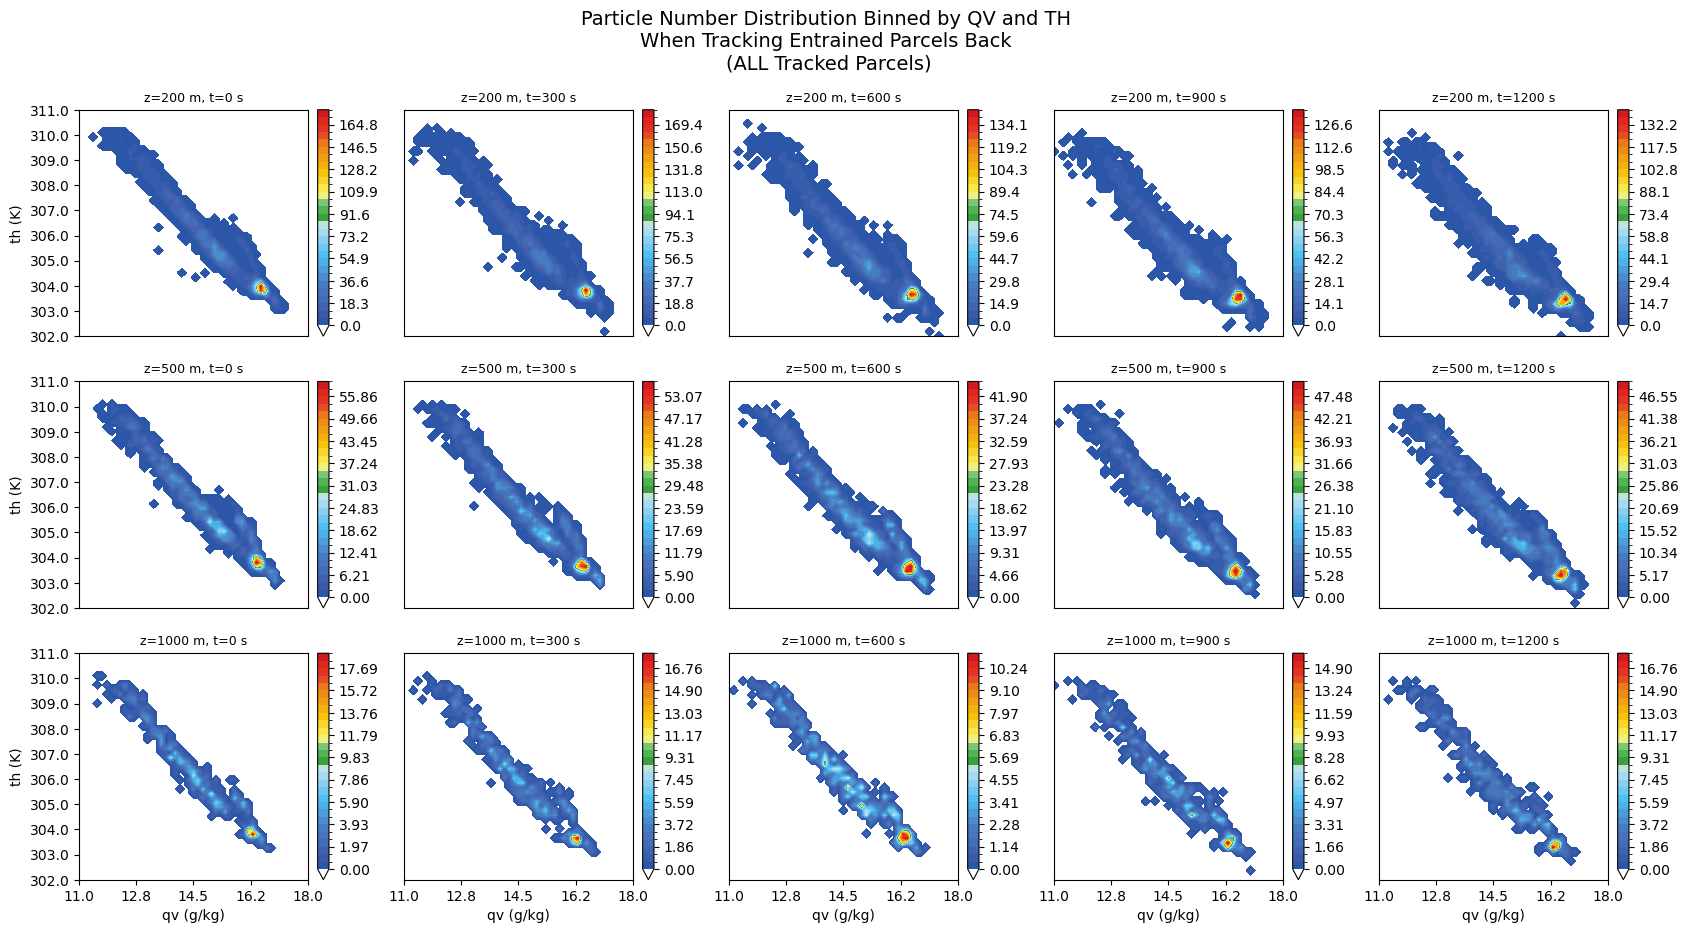

In [198]:
if plotting == True:
    def format_axes(ax, i, j, nrows, ncols, bin_array, xlabel="X-axis label", ylabel="Y-axis label"):
        if i == nrows - 1:
            num_bins=5
            ax.set_xlabel(xlabel)
            x_ticks_positions=np.linspace(bin_left1*1000,bin_right1*1000,num_bins)
            ax.set_xticks(np.linspace(0,bin_array.shape[1],num_bins));
            ax.set_xticklabels([f'{p:.1f}' for p in x_ticks_positions]);
        else:
            ax.set_xticks([])
    
        if j == 0:
            num_bins=10
            ax.set_ylabel(ylabel)
            y_ticks_positions=np.linspace(bin_left2,bin_right2,num_bins)
            ax.set_yticks(np.linspace(0,bin_array.shape[1],num_bins));
            ax.set_yticklabels([f'{p:.1f}' for p in y_ticks_positions]);
        else:
            ax.set_yticks([])


    def plot_histogram_grid(data_dict, histz_vals, histt_vals, xlabel,ylabel):
        fig = plt.figure(figsize=(20, 10))
        gs = gridspec.GridSpec(len(histz_vals), len(histt_vals), figure=fig, wspace=0.3, hspace=0.2)
    
        for i, z in enumerate(histz_vals):
            for j, (t, t_int) in enumerate(zip(histt_vals,intervals)):
                key = f'{z}_{t}'
                ax = fig.add_subplot(gs[i, j])
                
                if key in data_dict:
                    bin_array = data_dict[key]
                    [custom_cmap, norm, levels] = initialize_colorbar(bin_array, num_contour_levels=30)
                    im = ax.contourf(bin_array, levels=levels, cmap=custom_cmap, norm=norm, extend='min')
                    
                    ax.set_title(f'z={z} m, t={t_int} s', fontsize=9)
                    format_axes(ax, i, j, len(histz_vals), len(histt_vals), 
                                bin_array, xlabel=xlabel, ylabel=ylabel)
                    fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
                else:
                    ax.axis('off')
    
        fig.suptitle(f'Particle Number Distribution Binned by QV and {VAR2_name.upper()} \nWhen Tracking Entrained Parcels Back \n(ALL Tracked Parcels)', fontsize=14)
    
    histz_vals = ['200', '500', '1000']  # unit: meters
    histt_vals = ['0', '300', '600', '900', '1200']  # unit: seconds
    plot_histogram_grid(Dictionary, histz_vals, histt_vals, xlabel="qv (g/kg)",ylabel=f"{VAR2_name} {VAR2_unit}")